In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Desafio Lisbon Dataset
Considerando as tabelas ecomerce e clientes responda:
1. Qual o host que ganha mais dinheiro em média no total?
2. Faça uma analise por cidade e por host. Existe algum host que trabalha em mais de uma cidade?
3. Qual pais no total lucrou mais?
4. Cidade de portugal que mais lucrou?
5. Faça um boxplot para comparar as distribuições de quanto se paga por noite em Lisboa e Porto. Qual cidade tem a maior mediana? Qual cidade tem mais outliers?
6. Quais as 10 amenidades mais comuns em Lisboa?
7. Qual o mês de maior lucro em Lisboa?
8. Qual a média de banheiros por cidade?
9. Crie uma coluna de review com base na média de todos as colunas de review e apresente a cidade com a maior média fora de portugal.

In [2]:
#read txt from ./data folder
airbnb = pd.read_csv("./data/lisbon.csv")
airbnb

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6499,https://www.airbnb.com/rooms/6499,20250308054758,2025-03-16,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...","To get to the city center, tram 15 stops in f...",https://a0.muscache.com/pictures/6422ee92-c84e...,14455,...,4.89,4.84,4.40,NaN,t,1,1,0,0,0.64
1,25659,https://www.airbnb.com/rooms/25659,20250308054758,2025-03-09,city scrape,Heart of Alfama - Le cœur d'Alfama (3 people),Charming apartment in Lisbon's historic Alfama...,"The Alfama neighborhood, is the oldest and mos...",https://a0.muscache.com/pictures/miso/Hosting-...,107347,...,4.95,4.87,4.82,56539/AL.,t,1,1,0,0,1.62
2,29396,https://www.airbnb.com/rooms/29396,20250308054758,2025-03-11,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,Great neighborhood in the old part of town. Am...,https://a0.muscache.com/pictures/163913/7d622c...,126415,...,4.92,4.87,4.73,28737/AL,t,1,1,0,0,2.67
3,29720,https://www.airbnb.com/rooms/29720,20250308054758,2025-03-09,city scrape,TheHOUSE - Your luxury home,"A house at the top of an anonimous building, T...","Location in the city's Embassies area, near en...",https://a0.muscache.com/pictures/7c977dcc-57d0...,128075,...,4.97,4.87,4.70,55695/AL,f,1,1,0,0,0.82
4,29915,https://www.airbnb.com/rooms/29915,20250308054758,2025-03-16,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,"Location:<br />Entrecampos, Avenida das Forças...",https://a0.muscache.com/pictures/9b572932-8d23...,128890,...,4.63,4.61,4.54,85851/AL.,f,1,1,0,0,0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24259,1371008748532246224,https://www.airbnb.com/rooms/1371008748532246224,20250308054758,2025-03-11,city scrape,Mary Pink - NO. 3A - Glowing Two-Bedroom Apart...,"In Lisbon, Mary Pink - NO 3A - Sublime Two-Bed...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,681544290,...,NaN,NaN,NaN,123603/AL,t,8,8,0,0,NaN
24260,1371091268401865721,https://www.airbnb.com/rooms/1371091268401865721,20250308054758,2025-03-09,city scrape,Large Bairro Alto B up to 22guests by Central ...,This spacious apartment managed by Central Hil...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,2681397,...,NaN,NaN,NaN,57703/AL,t,34,34,0,0,NaN
24261,1371216308686882761,https://www.airbnb.com/rooms/1371216308686882761,20250308054758,2025-03-11,city scrape,Central Lisbon flat Saldanha,The whole group will enjoy easy access to ever...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,1442868,...,NaN,NaN,NaN,12345/AL,t,1,1,0,0,NaN
24262,1371223704329486155,https://www.airbnb.com/rooms/1371223704329486155,20250308054758,2025-03-09,city scrape,Nils ”Nisse” Lisboa,“Meet Nisse – Your Perfect Traveler!”<br /><br...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,49977054,...,NaN,NaN,NaN,Exempt,t,1,1,0,0,NaN


In [3]:
#qual host ganha em média mais por noite?
airbnb["price"] = airbnb["price"].str.replace("$","").str.replace(",","").astype(float)
airbnb["income"] = airbnb["price"]*airbnb["minimum_nights"]

income_host = airbnb.groupby("host_id")["income"].mean().round()
income_host.sort_values(ascending=False).head()

host_id
302071274    2400133.0
10669477      335750.0
305051606     160000.0
498826861     109865.0
27090866       69350.0
Name: income, dtype: float64

In [35]:
airbnb[airbnb["host_id"] == 302071274][['host_location','host_id']]

,host_location,host_id
13895,"Lisbon, Portugal",302071274
16591,"Lisbon, Portugal",302071274
17335,"Lisbon, Portugal",302071274


In [4]:
#convert host_location in collumn city e pais
airbnb["city"] = airbnb["host_location"].str.split(", ", n=1).str[0]
airbnb["country"] = airbnb["host_location"].str.split(", ", n=1).str[1]

#if airbnb["host_location"] == "Portugal":
#    airbnb["city"] = "NaN"
#    airbnb["country"] = "Portugal"
airbnb.loc[
    airbnb["host_location"] == "Portugal",
    ["city", "country"]
] = [np.nan, "Portugal"]


#group by city and host
city_host = airbnb.groupby(["city","host_id"])["income"].mean()
city_host

city                      host_id  
A Coruña                  457254284      60.000000
A dos Cunhados            31395821      257.000000
                          105919842     486.000000
A dos Cunhados e Maceira  132780196     183.500000
                          185384713            NaN
                                          ...     
İstanbul                  5709594        59.000000
                          15491838     1708.333333
                          65333393      315.000000
                          73733717      360.000000
                          437469007     714.000000
Name: income, Length: 6521, dtype: float64

In [5]:
#count host by city
host_city_count = airbnb.groupby("host_id")["city"].nunique()
host_city_count[host_city_count > 1]

Series([], Name: city, dtype: int64)

In [6]:
#count city by host
city_host_count = airbnb.groupby("city")["host_id"].nunique()
city_host_count.sort_values(ascending=False)

city
Lisbon              3861
Cascais              276
Sintra               219
Ericeira             185
Estoril              105
                    ... 
Golden                 1
Germiston              1
Genval                 1
Geneva                 1
Lord Howe Island       1
Name: host_id, Length: 577, dtype: int64

In [7]:
#pais que mais lucrou
country_income = airbnb.groupby("country")["income"].sum()
country_income.sort_values(ascending=False)

country
Portugal          16295111.0
France              165878.0
United Kingdom       83537.0
Oman                 49410.0
Spain                49071.0
                     ...    
Hong Kong                0.0
OK                       0.0
Iceland                  0.0
Mongolia                 0.0
Maldives                 0.0
Name: income, Length: 72, dtype: float64

In [8]:
#cidade que mais lucrou
country_income = airbnb.groupby("city")["income"].sum()
country_income.sort_values(ascending=False)

city
Lisbon              13416725.0
Estoril               428416.0
Cascais               362754.0
Faro                  309751.0
Sintra                188857.0
                       ...    
Heywood                    0.0
Hamilton                   0.0
Fortaleza                  0.0
Ferney-Voltaire            0.0
Hong Kong Island           0.0
Name: income, Length: 577, dtype: float64

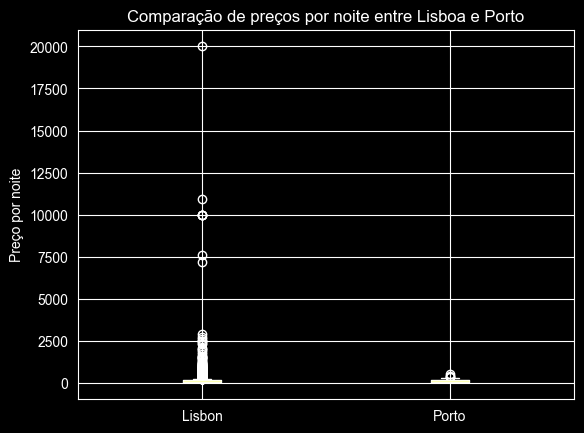

In [9]:

# drop na coluna income
sem_income = airbnb.dropna(subset=["income"])

# comparar as distribuições em quanto se paga por noite em lisboa e porto
lisboa = sem_income[sem_income["city"] == "Lisbon"]
porto = sem_income[sem_income["city"] == "Porto"]

# fazer boxplot para comparar as distribuições
plt.boxplot(
    [lisboa["price"], porto["price"]],
    tick_labels=["Lisbon", "Porto"]
)

plt.ylabel("Preço por noite")
plt.title("Comparação de preços por noite entre Lisboa e Porto")
plt.show()

In [10]:
#mediana das duas cidades
print(lisboa["price"].median())
print(porto["price"].median())

88.0
80.0


In [11]:
# quantidade de outliers

# primeiro calculo IQR
IQR_porto = porto["price"].quantile(0.75) - porto["price"].quantile(0.25)

# calculo os limites inferior e superior
lower_limit = porto["price"].quantile(0.25) - 1.5 * IQR_porto
upper_bound = porto["price"].quantile(0.75) + 1.5 * IQR_porto

# contar quantidade de outliers
outliers_porto = porto[
    (porto["price"] < lower_limit) |
    (porto["price"] > upper_bound)
]

print(len(outliers_porto))

4


In [12]:
# quantidade de outliers em Lisboa

# calcular Q1 e Q3
q1 = lisboa["price"].quantile(0.25)
q3 = lisboa["price"].quantile(0.75)

# calcular IQR
iqr = q3 - q1

# limites
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# identificar outliers
outliers_lisboa = lisboa[
    (lisboa["price"] < lower_limit) |
    (lisboa["price"] > upper_limit)
]

# quantidade
print(len(outliers_lisboa))

677


In [13]:
#qual as 10 amenidade mais comum em Lisboa
#explodir a coluna amenities
lisboa_amenities = lisboa["amenities"].str.split(",").explode()
#remove os espaços em branco
lisboa_amenities = lisboa_amenities.str.strip()
#remove as aspas
lisboa_amenities = lisboa_amenities.str.replace('"', "")
#remove os colchetes
lisboa_amenities = lisboa_amenities.str.replace("[", "").str.replace("]", "")
#contar as amenidades mais comuns
lisboa_amenities.value_counts().head(10)

amenities
Kitchen                  9587
Wifi                     9198
Hot water                8900
Hair dryer               8880
Essentials               8637
Iron                     8456
Hangers                  8361
Dishes and silverware    8274
Cooking basics           8048
Refrigerator             8037
Name: count, dtype: int64

In [14]:
#mes de maior lucro em Lisboa
#converter a coluna last_review para datetime
lisboa["last_review"] = pd.to_datetime(lisboa["last_review"], errors="coerce")
#extrair o mês e o ano da coluna last_review
lisboa["month"] = lisboa["last_review"].dt.month
lisboa["year"] = lisboa["last_review"].dt.year
#calcular o lucro por mês
lisboa["income_month"] = lisboa["price"] * lisboa["minimum_nights"]
#agrupar por mês e calcular o lucro total
income_by_month = lisboa.groupby("month")["income_month"].sum()
income_by_month.sort_values(ascending=False)

month
10.0    7549441.0
2.0      820471.0
1.0      502205.0
3.0      486651.0
9.0      404893.0
8.0      374680.0
11.0     300914.0
7.0      190782.0
12.0     185603.0
6.0      123332.0
5.0      105075.0
4.0       63756.0
Name: income_month, dtype: float64

In [15]:
airbnb

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,income,city,country
0,6499,https://www.airbnb.com/rooms/6499,20250308054758,2025-03-16,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...","To get to the city center, tram 15 stops in f...",https://a0.muscache.com/pictures/6422ee92-c84e...,14455,...,NaN,t,1,1,0,0,0.64,219.0,Brussels,Belgium
1,25659,https://www.airbnb.com/rooms/25659,20250308054758,2025-03-09,city scrape,Heart of Alfama - Le cœur d'Alfama (3 people),Charming apartment in Lisbon's historic Alfama...,"The Alfama neighborhood, is the oldest and mos...",https://a0.muscache.com/pictures/miso/Hosting-...,107347,...,56539/AL.,t,1,1,0,0,1.62,212.0,Lisbon,Portugal
2,29396,https://www.airbnb.com/rooms/29396,20250308054758,2025-03-11,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,Great neighborhood in the old part of town. Am...,https://a0.muscache.com/pictures/163913/7d622c...,126415,...,28737/AL,t,1,1,0,0,2.67,225.0,Lisbon,Portugal
3,29720,https://www.airbnb.com/rooms/29720,20250308054758,2025-03-09,city scrape,TheHOUSE - Your luxury home,"A house at the top of an anonimous building, T...","Location in the city's Embassies area, near en...",https://a0.muscache.com/pictures/7c977dcc-57d0...,128075,...,55695/AL,f,1,1,0,0,0.82,2130.0,NaN,NaN
4,29915,https://www.airbnb.com/rooms/29915,20250308054758,2025-03-16,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,"Location:<br />Entrecampos, Avenida das Forças...",https://a0.muscache.com/pictures/9b572932-8d23...,128890,...,85851/AL.,f,1,1,0,0,0.34,570.0,New York,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24259,1371008748532246224,https://www.airbnb.com/rooms/1371008748532246224,20250308054758,2025-03-11,city scrape,Mary Pink - NO. 3A - Glowing Two-Bedroom Apart...,"In Lisbon, Mary Pink - NO 3A - Sublime Two-Bed...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,681544290,...,123603/AL,t,8,8,0,0,NaN,14822.0,NaN,NaN
24260,1371091268401865721,https://www.airbnb.com/rooms/1371091268401865721,20250308054758,2025-03-09,city scrape,Large Bairro Alto B up to 22guests by Central ...,This spacious apartment managed by Central Hil...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,2681397,...,57703/AL,t,34,34,0,0,NaN,200.0,Lisbon,Portugal
24261,1371216308686882761,https://www.airbnb.com/rooms/1371216308686882761,20250308054758,2025-03-11,city scrape,Central Lisbon flat Saldanha,The whole group will enjoy easy access to ever...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,1442868,...,12345/AL,t,1,1,0,0,NaN,110.0,Brussels,Belgium
24262,1371223704329486155,https://www.airbnb.com/rooms/1371223704329486155,20250308054758,2025-03-09,city scrape,Nils ”Nisse” Lisboa,“Meet Nisse – Your Perfect Traveler!”<br /><br...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,49977054,...,Exempt,t,1,1,0,0,NaN,59.0,Åkersberga,Sweden


In [16]:
banheiros_cidade = airbnb.groupby("city").agg(
    quantidade_imoveis=("listing_url", "count"),
    media_banheiros=("bathrooms", "mean")
)

banheiros_cidade.sort_values(by="quantidade_imoveis", ascending=False)

,quantidade_imoveis,media_banheiros
city,,
Lisbon,11612,1.428396
Cascais,657,1.564035
Ericeira,501,1.643705
Sintra,432,1.407652
Estoril,252,1.500000
...,...,...
Ir-Rabat,1,2.000000
India,1,1.500000
Iceland,1,3.000000


In [17]:
airbnb

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,income,city,country
0,6499,https://www.airbnb.com/rooms/6499,20250308054758,2025-03-16,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...","To get to the city center, tram 15 stops in f...",https://a0.muscache.com/pictures/6422ee92-c84e...,14455,...,NaN,t,1,1,0,0,0.64,219.0,Brussels,Belgium
1,25659,https://www.airbnb.com/rooms/25659,20250308054758,2025-03-09,city scrape,Heart of Alfama - Le cœur d'Alfama (3 people),Charming apartment in Lisbon's historic Alfama...,"The Alfama neighborhood, is the oldest and mos...",https://a0.muscache.com/pictures/miso/Hosting-...,107347,...,56539/AL.,t,1,1,0,0,1.62,212.0,Lisbon,Portugal
2,29396,https://www.airbnb.com/rooms/29396,20250308054758,2025-03-11,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,Great neighborhood in the old part of town. Am...,https://a0.muscache.com/pictures/163913/7d622c...,126415,...,28737/AL,t,1,1,0,0,2.67,225.0,Lisbon,Portugal
3,29720,https://www.airbnb.com/rooms/29720,20250308054758,2025-03-09,city scrape,TheHOUSE - Your luxury home,"A house at the top of an anonimous building, T...","Location in the city's Embassies area, near en...",https://a0.muscache.com/pictures/7c977dcc-57d0...,128075,...,55695/AL,f,1,1,0,0,0.82,2130.0,NaN,NaN
4,29915,https://www.airbnb.com/rooms/29915,20250308054758,2025-03-16,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,"Location:<br />Entrecampos, Avenida das Forças...",https://a0.muscache.com/pictures/9b572932-8d23...,128890,...,85851/AL.,f,1,1,0,0,0.34,570.0,New York,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24259,1371008748532246224,https://www.airbnb.com/rooms/1371008748532246224,20250308054758,2025-03-11,city scrape,Mary Pink - NO. 3A - Glowing Two-Bedroom Apart...,"In Lisbon, Mary Pink - NO 3A - Sublime Two-Bed...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,681544290,...,123603/AL,t,8,8,0,0,NaN,14822.0,NaN,NaN
24260,1371091268401865721,https://www.airbnb.com/rooms/1371091268401865721,20250308054758,2025-03-09,city scrape,Large Bairro Alto B up to 22guests by Central ...,This spacious apartment managed by Central Hil...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,2681397,...,57703/AL,t,34,34,0,0,NaN,200.0,Lisbon,Portugal
24261,1371216308686882761,https://www.airbnb.com/rooms/1371216308686882761,20250308054758,2025-03-11,city scrape,Central Lisbon flat Saldanha,The whole group will enjoy easy access to ever...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,1442868,...,12345/AL,t,1,1,0,0,NaN,110.0,Brussels,Belgium
24262,1371223704329486155,https://www.airbnb.com/rooms/1371223704329486155,20250308054758,2025-03-09,city scrape,Nils ”Nisse” Lisboa,“Meet Nisse – Your Perfect Traveler!”<br /><br...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,49977054,...,Exempt,t,1,1,0,0,NaN,59.0,Åkersberga,Sweden


In [18]:
#Crie uma coluna de review com base na média de todos as colunas de review e apresente a cidade com a maior média fora de portugal.
airbnb["review"] = airbnb[[
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]].mean(axis=1)

In [19]:
#filtrar apenas as cidades fora de portugal
fora_portugal = airbnb[airbnb["country"] != "Portugal"]
#agrupar por cidade e calcular a média de review
review_cidade = fora_portugal.groupby("city")["review"].mean()
review_cidade.sort_values(ascending=False).head(10)

city
Nantes              5.0
Washington          5.0
Hamilton            5.0
Oklahoma City       5.0
State of Alagoas    5.0
Pemba               5.0
Le Chesnay          5.0
Muscat              5.0
Fortaleza           5.0
Matola              5.0
Name: review, dtype: float64

### Desafio Lisbon Dataset
Considerando as tabelas ecomerce e clientes responda:
1. Use o dicionário em anexo para agregar colunas no dataset medical. Crie as colunas idh, populacao e violencia com base no dicionário.
2. Qual bairro possui o maior número de faltas (No-show)?
3. Existe relação entre violência do bairro e taxa de faltas?
4. Qual faixa de IDH apresenta menor taxa de comparecimento?
5. Qual gênero falta mais às consultas?
6. Pacientes que recebem SMS comparecem mais?
7. Qual mês possui mais faltas?
8. Qual bairro possui a população mais alta entre os que têm violência alta?
9. Faça um boxplot comparando a idade dos pacientes que faltaram e dos que compareceram.
10. Crie uma variável “tempo_espera” entre agendamento e consulta. Quem espera mais falta mais?

In [20]:
#read txt from ./data folder
medical = pd.read_csv("./data/medical.csv")
medical

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [21]:
indicadores_bairros = {
    'JARDIM DA PENHA': {
        'idh': 0.92,
        'populacao': 18500,
        'violencia': 'Baixa'
    },
    'MATA DA PRAIA': {
        'idh': 0.91,
        'populacao': 9200,
        'violencia': 'Baixa'
    },
    'PONTAL DE CAMBURI': {
        'idh': 0.88,
        'populacao': 4100,
        'violencia': 'Baixa'
    },
    'REPÚBLICA': {
        'idh': 0.73,
        'populacao': 7600,
        'violencia': 'Média'
    },
    'GOIABEIRAS': {
        'idh': 0.69,
        'populacao': 14500,
        'violencia': 'Média'
    },
    'ANDORINHAS': {
        'idh': 0.62,
        'populacao': 21000,
        'violencia': 'Alta'
    },
    'CONQUISTA': {
        'idh': 0.58,
        'populacao': 17000,
        'violencia': 'Alta'
    },
    'NOVA PALESTINA': {
        'idh': 0.55,
        'populacao': 26000,
        'violencia': 'Alta'
    },
    'DA PENHA': {
        'idh': 0.60,
        'populacao': 22000,
        'violencia': 'Alta'
    },
    'TABUAZEIRO': {
        'idh': 0.66,
        'populacao': 19500,
        'violencia': 'Média'
    },
    'BENTO FERREIRA': {
        'idh': 0.87,
        'populacao': 11200,
        'violencia': 'Baixa'
    },
    'SÃO PEDRO': {
        'idh': 0.57,
        'populacao': 31000,
        'violencia': 'Alta'
    },
    'JARDIM CAMBURI': {
        'idh': 0.90,
        'populacao': 42000,
        'violencia': 'Baixa'
    },
    'MARIA ORTIZ': {
        'idh': 0.71,
        'populacao': 28000,
        'violencia': 'Média'
    },
    'PRAIA DO CANTO': {
        'idh': 0.95,
        'populacao': 8300,
        'violencia': 'Baixa'
    },
    'BARRO VERMELHO': {
        'idh': 0.93,
        'populacao': 6400,
        'violencia': 'Baixa'
    },
    'SANTA LÚCIA': {
        'idh': 0.94,
        'populacao': 7100,
        'violencia': 'Baixa'
    },
    'CENTRO': {
        'idh': 0.74,
        'populacao': 15400,
        'violencia': 'Média'
    },
    'VILA RUBIM': {
        'idh': 0.59,
        'populacao': 9800,
        'violencia': 'Alta'
    },
    'ILHA DO BOI': {
        'idh': 0.98,
        'populacao': 2100,
        'violencia': 'Baixa'
    },
    'ILHA DO FRADE': {
        'idh': 0.97,
        'populacao': 1800,
        'violencia': 'Baixa'
    },
    'ROMÃO': {
        'idh': 0.63,
        'populacao': 13300,
        'violencia': 'Alta'
    },
    'CRUZAMENTO': {
        'idh': 0.68,
        'populacao': 12100,
        'violencia': 'Média'
    },
    'FORTE SÃO JOÃO': {
        'idh': 0.70,
        'populacao': 8900,
        'violencia': 'Média'
    },
    'SANTA TEREZA': {
        'idh': 0.65,
        'populacao': 14700,
        'violencia': 'Média'
    }
}


In [22]:
# #criar as colunas idh, populacao e violencia com base no dicionário
# medical["idh"] = medical["Neighbourhood"].map(lambda x: indicadores_bairros.get(x, {}).get("idh", np.nan))
# medical["populacao"] = medical["Neighbourhood"].map(lambda x: indicadores_bairros.get(x, {}).get("populacao", np.nan))
# medical["violencia"] = medical["Neighbourhood"].map(lambda x: indicadores_bairros.get(x, {}).get("violencia", np.nan))
# medical

In [23]:
#other way is create a dataframe with the dicionary and merge with medical
indicadores_df = pd.DataFrame.from_dict(indicadores_bairros, orient="index").reset_index().rename(columns={"index": "Neighbourhood"})
medical_merged = medical.merge(indicadores_df, on="Neighbourhood", how="left")
medical_merged

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,idh,populacao,violencia
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0.92,18500.0,Baixa
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0.92,18500.0,Baixa
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No,0.91,9200.0,Baixa
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0.88,4100.0,Baixa
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0.92,18500.0,Baixa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No,0.71,28000.0,Média
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No,0.71,28000.0,Média
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No,0.71,28000.0,Média
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No,0.71,28000.0,Média


In [24]:
#qual bairro possui o maior número de faltas (No-show)?
(
    medical_merged[medical_merged['No-show'] == 'Yes']
    .groupby('Neighbourhood')['No-show']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

Neighbourhood
JARDIM CAMBURI       1465
MARIA ORTIZ          1219
ITARARÉ               923
RESISTÊNCIA           906
CENTRO                703
JESUS DE NAZARETH     696
JARDIM DA PENHA       631
CARATOÍRA             591
TABUAZEIRO            573
BONFIM                550
Name: No-show, dtype: int64

In [25]:
#Existe relação entre violência do bairro e taxa de faltas?
taxa_faltas = (
    medical_merged.groupby('violencia')['No-show']
    .apply(lambda x: (x == 'Yes').mean())
    .sort_values(ascending=False)
)

taxa_faltas

violencia
Alta     0.201587
Média    0.200651
Baixa    0.184231
Name: No-show, dtype: float64

In [26]:
#Qual faixa de IDH apresenta menor taxa de comparecimento?
medical_merged['faixa_idh'] = pd.cut(
    medical_merged['idh'],
    bins=[0, 0.6, 0.75, 1],
    labels=['Baixo', 'Médio', 'Alto']
)

(
    medical_merged.groupby('faixa_idh')['No-show']
    .apply(lambda x: (x == 'Yes').mean())
)

faixa_idh
Baixo    0.190868
Médio    0.204873
Alto     0.184231
Name: No-show, dtype: float64

In [27]:
#Qual gênero falta mais às consultas?
(
    medical_merged.groupby('Gender')['No-show']
    .apply(lambda x: (x == 'Yes').mean())
)

Gender
F    0.203146
M    0.199679
Name: No-show, dtype: float64

In [28]:
#Pacientes que recebem SMS comparecem mais?
(
    medical_merged.groupby(['SMS_received'])['No-show']
    .apply(lambda x: (x == 'No').mean())
)

SMS_received
0    0.832967
1    0.724255
Name: No-show, dtype: float64

In [29]:
#Qual mês possui mais faltas?
medical_merged['ScheduledDay'] = pd.to_datetime(medical_merged['ScheduledDay'])
medical_merged['AppointmentDay'] = pd.to_datetime(medical_merged['AppointmentDay'])

medical_merged['mes'] = medical_merged['AppointmentDay'].dt.month_name()

(
    medical_merged[medical_merged['No-show'] == 'Yes']
    .groupby('mes')['No-show']
    .count()
    .sort_values(ascending=False)
)

mes
May      16804
June      4882
April      633
Name: No-show, dtype: int64

In [30]:
#Qual bairro possui a população mais alta entre os que têm violência alta?
(
    medical_merged[medical_merged['violencia'] == 'Alta']
    [['Neighbourhood', 'populacao']]
    .drop_duplicates()
    .sort_values('populacao', ascending=False)
    .head(10)
)

,Neighbourhood,populacao
28,SÃO PEDRO,31000.0
10,NOVA PALESTINA,26000.0
19,DA PENHA,22000.0
8,ANDORINHAS,21000.0
9,CONQUISTA,17000.0
717,ROMÃO,13300.0
835,VILA RUBIM,9800.0


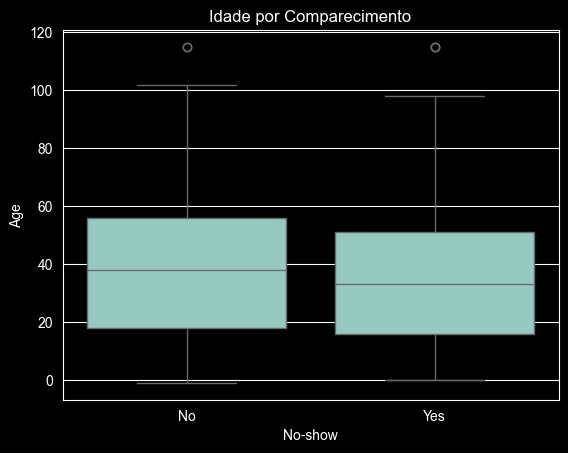

In [31]:
#Faça um boxplot comparando a idade dos pacientes que faltaram e dos que compareceram.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=medical_merged,
    x='No-show',
    y='Age'
)

plt.title('Idade por Comparecimento')
plt.show()

In [32]:
#Crie uma variável “tempo_espera” entre agendamento e consulta. Quem espera mais falta mais?
medical_merged['tempo_espera'] = (
    medical_merged['AppointmentDay'] - medical_merged['ScheduledDay']
).dt.days

(
    medical_merged.groupby('No-show')['tempo_espera']
    .mean()
)

No-show
No      7.754659
Yes    14.831489
Name: tempo_espera, dtype: float64